In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv
/kaggle/input/datasets/ommore1234/quantum-risk-data/corrected_banking_stream.json
/kaggle/input/datasets/ommore1234/sample-set/synthetic_stream_full_1000.json


In [ ]:
import pandas as pd, numpy as np

def balanced_downsample(df, label_col, total_n, seed=42):
    """Greedy-balanced downsample: tries equal rows per class; classes too
    small to hit that target keep ALL their rows, and the leftover budget
    is redistributed equally among the remaining (larger) classes."""
    classes = df[label_col].unique()
    counts = df[label_col].value_counts().to_dict()
    remaining_classes = list(classes)
    budget = total_n
    alloc = {}

    while remaining_classes:
        target = budget // len(remaining_classes)
        settled = [c for c in remaining_classes if counts[c] <= target]
        if not settled:
            for c in remaining_classes:
                alloc[c] = target
            break
        for c in settled:
            alloc[c] = counts[c]
            budget -= counts[c]
        remaining_classes = [c for c in remaining_classes if c not in settled]

    parts = [df[df[label_col] == c].sample(n=alloc[c], random_state=seed) for c in alloc]
    out = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f"[{label_col}] downsampled to {len(out)} rows -> {out[label_col].value_counts().to_dict()}")
    return out

KEEP_CLASSES = ["BENIGN", "DoS GoldenEye", "DoS Hulk", "DoS Slowhttptest", "FTP-Patator"]

import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

def train_with_guardrails(X, y, params_override=None):
    """Binary-classification training with regularization + early stopping +
    train/test AUC gap check + 5-fold CV, to keep the small downsampled
    dataset from overfitting.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )

    params = dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        min_child_weight=5,
        tree_method='hist',
        enable_categorical=True,
        eval_metric="auc",
        early_stopping_rounds=30,
        random_state=42,
    )
    if params_override:
        params.update(params_override)

    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=50)

    from sklearn.metrics import roc_auc_score
    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"Train AUC: {train_auc:.4f} | Test AUC: {test_auc:.4f} | Gap: {train_auc - test_auc:.4f}")
    if train_auc - test_auc > 0.05:
        print("WARNING: gap > 0.05 -- likely overfitting, reduce max_depth or add more regularization")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_params = {k: v for k, v in params.items() if k != "early_stopping_rounds"}
    cv_scores = cross_val_score(xgb.XGBClassifier(**cv_params), X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

    return model, (X_test, y_test), X


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = "/kaggle/input/competitions/ieee-fraud-detection"
txn = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")
identity = pd.read_csv(f"{DATA_DIR}/train_identity.csv")
df = txn.merge(identity, on="TransactionID", how="left")

print(f"Data loaded. Shape: {df.shape}")

df = balanced_downsample(df, "isFraud", total_n=10_000)

y = df['isFraud']

X = df.drop(['isFraud', 'TransactionID', 'TransactionDT'], axis=1)

for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna("missing").astype("category")

print("Training XGBoost Model...")
clf, (X_valid, y_valid), X_train_used = train_with_guardrails(X, y)

preds_proba = clf.predict_proba(X_valid)[:, 1]
preds_class = clf.predict(X_valid)

auc = roc_auc_score(y_valid, preds_proba)
print(f"\n--- Model Evaluation ---")
print(f"Validation ROC-AUC Score: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_valid, preds_class))

model_filename = "xgboost_fraud_model.json"
clf.save_model(model_filename)
print(f"Model saved successfully to {model_filename}!")
print(df.columns.tolist())


Data loaded. Shape: (590540, 434)
[isFraud] downsampled to 10000 rows -> {1: 5000, 0: 5000}
Training XGBoost Model...
[0]	validation_0-auc:0.81695	validation_1-auc:0.80681
[50]	validation_0-auc:0.88587	validation_1-auc:0.86959
[100]	validation_0-auc:0.90637	validation_1-auc:0.88171
[150]	validation_0-auc:0.92004	validation_1-auc:0.88991
[200]	validation_0-auc:0.92968	validation_1-auc:0.89434
[250]	validation_0-auc:0.93709	validation_1-auc:0.89742
[300]	validation_0-auc:0.94387	validation_1-auc:0.90071
[350]	validation_0-auc:0.94976	validation_1-auc:0.90228
[400]	validation_0-auc:0.95502	validation_1-auc:0.90382
[450]	validation_0-auc:0.95979	validation_1-auc:0.90542
[499]	validation_0-auc:0.96351	validation_1-auc:0.90670
Train AUC: 0.9635 | Test AUC: 0.9147 | Gap: 0.0488
5-fold CV AUC: 0.9010 +/- 0.0055

--- Model Evaluation ---
Validation ROC-AUC Score: 0.9147

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83    

In [ ]:
import joblib

cat_maps = {
    c: X_train_used[c].cat.categories.tolist()
    for c in X_train_used.columns
    if str(X_train_used[c].dtype) == "category"
}
joblib.dump(cat_maps, "fraud_category_maps.joblib")
print(f"Saved {len(cat_maps)} category maps -> fraud_category_maps.joblib")


Saved 31 category maps -> fraud_category_maps.joblib


In [5]:
!pip install -q gdown shap

In [6]:
import gdown, os

FOLDER_ID = "1s3DdK5p-tNkYU9HP3b9UNepD3lorA1PX"
gdown.download_folder(id=FOLDER_ID, output="/kaggle/working/cicids2017", quiet=False, use_cookies=False)

Retrieving folder contents


Retrieving folder 1ozyU0oTBV0xOXaS2tYdmvujFXeVB9OH_ MachineLearningCSV
Retrieving folder 1AGS3rOpOVBdrcWhSSectgo5LtYvTuUl4 MachineLearningCVE
Processing file 1cCOGSns3-sfWggl2JOH-zsaEL0OoZWP3 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing file 1uAXpRb8brS5_HfMFQ0v0LrUv7p4kMXii Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing file 1IDcDkvY_KhwerbcW9VSTI4g2q8Lj9H5p Friday-WorkingHours-Morning.pcap_ISCX.csv
Processing file 1V2X-1ls_MXvPLjl0g_iZQ3rToNX18k7i Monday-WorkingHours.pcap_ISCX.csv
Processing file 1u26MhaSRBB4sePPEpkjT2cWcGl1u3Z68 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing file 1S5DP7TnQh2Q2BEpHiGKh7ql4J6utqHNq Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing file 18RdKnG8g6842amqU8DMsV6Kb0fEqhixm Tuesday-WorkingHours.pcap_ISCX.csv
Processing file 1oXsHK3a5lOSaB4DzMBA-ylEEwKB2Auiq Wednesday-workingHours.pcap_ISCX.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1cCOGSns3-sfWggl2JOH-zsaEL0OoZWP3
To: /kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
100%|██████████| 77.1M/77.1M [00:00<00:00, 89.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1uAXpRb8brS5_HfMFQ0v0LrUv7p4kMXii
To: /kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
100%|██████████| 76.9M/76.9M [00:00<00:00, 91.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IDcDkvY_KhwerbcW9VSTI4g2q8Lj9H5p
To: /kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
100%|██████████| 58.3M/58.3M [00:00<00:00, 65.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1V2X-1ls_MXvPLjl0g_iZQ3rToNX18k7i
From (redirected): https://dri

['/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv',
 '/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv']

In [ ]:
CIC_DIR = "/kaggle/working/cicids2017/MachineLearningCSV/MachineLearningCVE"
cyber_benign = pd.read_csv(f"{CIC_DIR}/Monday-WorkingHours.pcap_ISCX.csv")
cyber_brute  = pd.read_csv(f"{CIC_DIR}/Tuesday-WorkingHours.pcap_ISCX.csv")
cyber_dos    = pd.read_csv(f"{CIC_DIR}/Wednesday-workingHours.pcap_ISCX.csv")

cyber = pd.concat([cyber_benign, cyber_brute, cyber_dos], ignore_index=True)
cyber.columns = cyber.columns.str.strip()
cyber.replace([np.inf, -np.inf], np.nan, inplace=True)
cyber.dropna(inplace=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import joblib

cyber = pd.concat(
    [cyber_benign, cyber_brute, cyber_dos],
    ignore_index=True
)

cyber.columns = cyber.columns.str.strip()

cyber.replace([np.inf, -np.inf], np.nan, inplace=True)

cyber.dropna(inplace=True)

cyber.drop_duplicates(inplace=True)

cyber = cyber[cyber["Label"].isin(KEEP_CLASSES)]
cyber = balanced_downsample(cyber, "Label", total_n=50_000)

drop_cols = [
    "Label",
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

drop_cols = [c for c in drop_cols if c in cyber.columns]

X = cyber.drop(columns=drop_cols)

y = cyber["Label"]

le = LabelEncoder()

y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))

print(classification_report(
    y_test,
    pred,
    target_names=le.classes_
))


[Label] downsampled to 49999 rows -> {'BENIGN': 14277, 'DoS Hulk': 14277, 'DoS GoldenEye': 10286, 'FTP-Patator': 5931, 'DoS Slowhttptest': 5228}
Accuracy : 0.9989
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00      2856
   DoS GoldenEye       1.00      1.00      1.00      2057
        DoS Hulk       1.00      1.00      1.00      2855
DoS Slowhttptest       1.00      1.00      1.00      1046
     FTP-Patator       1.00      1.00      1.00      1186

        accuracy                           1.00     10000
       macro avg       1.00      1.00      1.00     10000
    weighted avg       1.00      1.00      1.00     10000



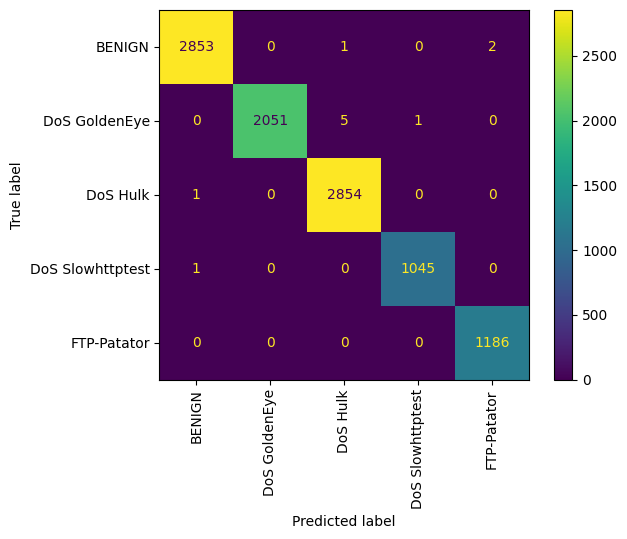

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=le.classes_,
    xticks_rotation=90
)

In [9]:
print(X.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [ ]:
train_pred = model.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))

fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi.head(10))

if "Destination Port" in X.columns:
    print("WARNING: Destination Port present — likely trivial leakage for FTP-Patator")

Train accuracy: 0.9998749968749219
Bwd Header Length              0.104325
Subflow Bwd Bytes              0.099476
Fwd IAT Std                    0.087298
Idle Max                       0.071382
Fwd PSH Flags                  0.059450
Min Packet Length              0.054013
Avg Bwd Segment Size           0.052191
Destination Port               0.037190
Active Mean                    0.036761
Total Length of Bwd Packets    0.029321
dtype: float32


In [11]:
import pandas as pd

fi = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(fi.sort_values("Importance", ascending=False).head(20))

                        Feature  Importance
35            Bwd Header Length    0.104325
65            Subflow Bwd Bytes    0.099476
22                  Fwd IAT Std    0.087298
76                     Idle Max    0.071382
30                Fwd PSH Flags    0.059450
38            Min Packet Length    0.054013
54         Avg Bwd Segment Size    0.052191
0              Destination Port    0.037190
70                  Active Mean    0.036761
5   Total Length of Bwd Packets    0.029321
43               FIN Flag Count    0.026188
40           Packet Length Mean    0.018349
44               SYN Flag Count    0.017334
46               PSH Flag Count    0.017118
27                  Bwd IAT Std    0.016842
37                Bwd Packets/s    0.016154
21                 Fwd IAT Mean    0.015710
11        Bwd Packet Length Min    0.014529
17                 Flow IAT Std    0.013551
2             Total Fwd Packets    0.011747


In [12]:
import joblib

joblib.dump(model, "cyber_xgboost_model.joblib")
joblib.dump(le, "cyber_label_encoder.joblib")
joblib.dump(list(X.columns), "cyber_feature_columns.joblib")

['cyber_feature_columns.joblib']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import joblib

# 1. Load your enriched synthetic data
print("Loading Enriched Banking Stream...")
df = pd.read_json("/kaggle/input/datasets/ommore1234/quantum-risk-data/corrected_banking_stream.json")

# 2. Select ONLY the Quantum/Physics Features
quantum_features = ['size_mb', 'Payload_Entropy', 'flow_duration', 'flow_bytes_per_s']
X_quantum = df[quantum_features]

print(f"Training Quantum Risk Model on {X_quantum.shape[0]} events...")

# 3. Train the Isolation Forest
iso_forest_quantum = IsolationForest(
    n_estimators=100,
    contamination=0.15,
    random_state=42,
    n_jobs=-1
)

# Fit the model
iso_forest_quantum.fit(X_quantum)

# 4. Extract Min/Max Bounds for Real-Time Streaming
raw_scores = iso_forest_quantum.decision_function(X_quantum)
score_min = float(raw_scores.min())
score_max = float(raw_scores.max())

# Calculate pseudo risk score for our sanity check using the static bounds
risk_scores = 100 - (((raw_scores - score_min) / (score_max - score_min)) * 100)
df['Quantum_Risk_Score'] = risk_scores.round(2)

print("\n--- Sanity Check: Top 5 Highest Quantum Risk Events ---")
highest_risk = df.sort_values(by='Quantum_Risk_Score', ascending=False).head(5)
print(highest_risk[['user', 'event_action', 'size_mb', 'Payload_Entropy', 'flow_bytes_per_s', 'Quantum_Risk_Score']])

# 5. Save the Model AND the Scaling Bounds
model_artifact = {
    "model": iso_forest_quantum,
    "score_min": score_min,
    "score_max": score_max,
    "features": quantum_features
}

model_filename = "quantum_risk_engine.joblib"
joblib.dump(model_artifact, model_filename)
print(f"\nBOOM! Production-Ready Quantum Model saved to {model_filename}")

Loading Enriched Banking Stream...
Training Quantum Risk Model on 88 events...

--- Sanity Check: Top 5 Highest Quantum Risk Events ---
       user     event_action  size_mb  Payload_Entropy  flow_bytes_per_s  \
60  Charlie       Encryption     2816           7.9792      2.590167e+10   
27  Charlie  Database Export     2148           5.7560      2.396108e+10   
10     Emma            Login      787           5.6250      1.195985e+10   
32    Alice          Archive     1101           4.8679      1.749215e+10   
3     Alice     Cloud Upload       77           7.9714      5.242880e+08   

    Quantum_Risk_Score  
60              100.00  
27               83.14  
10               68.45  
32               65.96  
3                62.55  

BOOM! Production-Ready Quantum Model saved to quantum_risk_engine.joblib
